# Project:- Marijuana Crime Analysis

# Import libraries 

In [110]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly as pl 
from sklearn.model_selection import train_test_split

# Load the Data

In [111]:
df = pd.read_csv('/Users/shyamalkar/Desktop/DS_project/Dataset_only/crime_marijuana.csv')

# Data clean 

In [112]:
df.head()

,INCIDENT_ID,FIRST_OCCURENCE_DATE,LAST_OCCURENCE_DATE,REPORTDATE,INCIDENT_ADDRESS,GEO_X,GEO_Y,DISTRICT_ID,PRECINCT_ID,OFFENSE_CODE,OFFENSE_TYPE_ID,OFFENSE_CATEGORY_ID,MJ_RELATION_TYPE,NEIGHBORHOOD_ID
0,2017151765,06-MAR-17,06-MAR-17,06-MAR-17,2207 N HOOKER ST,3132526.0,1698468.0,1,121,3563,DRUG - MARIJUANA CULTIVATION,Drug Offenses,NON-INDUSTRY\r,sloan-lake
1,20184912,03-JAN-18,03-JAN-18,03-JAN-18,4400 E EVANS AVE,3158749.0,1672408.0,3,314,2205,BURGLARY - BUSINESS NO FORCE,Burglary,INDUSTRY\r,university-hills
2,20184942,03-JAN-18,03-JAN-18,03-JAN-18,3435 S YOSEMITE ST,3173094.0,1663993.0,3,323,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,hampden
3,201666719,01-FEB-16,01-FEB-16,01-FEB-16,5050 N YORK ST,3152054.0,1712498.0,2,212,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,elyria-swansea
4,2016317585,21-MAY-16,21-MAY-16,21-MAY-16,3888 E MEXICO AVE,3157004.0,1674967.0,3,312,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,cory-merrill


In [113]:
column = df['NEIGHBORHOOD_ID'].head()
column

0          sloan-lake
1    university-hills
2             hampden
3      elyria-swansea
4        cory-merrill
Name: NEIGHBORHOOD_ID, dtype: str

In [114]:
# remove multiple columns 
new_df = df.drop(columns=['INCIDENT_ID','INCIDENT_ADDRESS'])
df = new_df
df.head()

,FIRST_OCCURENCE_DATE,LAST_OCCURENCE_DATE,REPORTDATE,GEO_X,GEO_Y,DISTRICT_ID,PRECINCT_ID,OFFENSE_CODE,OFFENSE_TYPE_ID,OFFENSE_CATEGORY_ID,MJ_RELATION_TYPE,NEIGHBORHOOD_ID
0,06-MAR-17,06-MAR-17,06-MAR-17,3132526.0,1698468.0,1,121,3563,DRUG - MARIJUANA CULTIVATION,Drug Offenses,NON-INDUSTRY\r,sloan-lake
1,03-JAN-18,03-JAN-18,03-JAN-18,3158749.0,1672408.0,3,314,2205,BURGLARY - BUSINESS NO FORCE,Burglary,INDUSTRY\r,university-hills
2,03-JAN-18,03-JAN-18,03-JAN-18,3173094.0,1663993.0,3,323,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,hampden
3,01-FEB-16,01-FEB-16,01-FEB-16,3152054.0,1712498.0,2,212,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,elyria-swansea
4,21-MAY-16,21-MAY-16,21-MAY-16,3157004.0,1674967.0,3,312,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,cory-merrill


In [115]:
df.columns

Index(['FIRST_OCCURENCE_DATE', 'LAST_OCCURENCE_DATE', 'REPORTDATE', 'GEO_X',
       'GEO_Y', 'DISTRICT_ID', 'PRECINCT_ID', 'OFFENSE_CODE',
       'OFFENSE_TYPE_ID', 'OFFENSE_CATEGORY_ID', 'MJ_RELATION_TYPE',
       'NEIGHBORHOOD_ID'],
      dtype='str')

In [116]:
rndm_smple = df['LAST_OCCURENCE_DATE'].sample()

print(rndm_smple)

21    NaN
Name: LAST_OCCURENCE_DATE, dtype: str


In [127]:
# How many missing values has in dataset 
df.isnull().sum()

FIRST_OCCURENCE_DATE    0
LAST_OCCURENCE_DATE     0
GEO_X                   0
GEO_Y                   0
DISTRICT_ID             0
PRECINCT_ID             0
OFFENSE_CODE            0
OFFENSE_TYPE_ID         0
OFFENSE_CATEGORY_ID     0
MJ_RELATION_TYPE        0
NEIGHBORHOOD_ID         0
REPORTDATE_year         0
REPORTDATE_month        0
REPORTDATE_day          0
REPORTDATE_dayofweek    0
dtype: int64

In [118]:
df = df.fillna(True)

In [119]:
df.isnull().sum()

FIRST_OCCURENCE_DATE    0
LAST_OCCURENCE_DATE     0
REPORTDATE              0
GEO_X                   0
GEO_Y                   0
DISTRICT_ID             0
PRECINCT_ID             0
OFFENSE_CODE            0
OFFENSE_TYPE_ID         0
OFFENSE_CATEGORY_ID     0
MJ_RELATION_TYPE        0
NEIGHBORHOOD_ID         0
dtype: int64

In [120]:
import pandas as pd

# 1. Convert the text column 'REPORTDATE' into a standard datetime object
# %d = Day (06), %b = Short Month Name (MAR), %y = 2-digit Year (17)
df['REPORTDATE'] = pd.to_datetime(df['REPORTDATE'], format='%d-%b-%y')

# 2. Now you can extract your machine learning features safely
df['REPORTDATE_year']  = df['REPORTDATE'].dt.year          # Extracts year (e.g., 2017)
df['REPORTDATE_month'] = df['REPORTDATE'].dt.month         # Extracts month (1-12)
df['REPORTDATE_day']   = df['REPORTDATE'].dt.day           # Extracts day (1-31)
df['REPORTDATE_dayofweek'] = df['REPORTDATE'].dt.dayofweek # Extracts day of week (0-6)

# 3. Drop the original text column so it doesn't cause errors in your model
df = df.drop(columns=['REPORTDATE'])


In [121]:
df.head()

,FIRST_OCCURENCE_DATE,LAST_OCCURENCE_DATE,GEO_X,GEO_Y,DISTRICT_ID,PRECINCT_ID,OFFENSE_CODE,OFFENSE_TYPE_ID,OFFENSE_CATEGORY_ID,MJ_RELATION_TYPE,NEIGHBORHOOD_ID,REPORTDATE_year,REPORTDATE_month,REPORTDATE_day,REPORTDATE_dayofweek
0,06-MAR-17,06-MAR-17,3132526.0,1698468.0,1,121,3563,DRUG - MARIJUANA CULTIVATION,Drug Offenses,NON-INDUSTRY\r,sloan-lake,2017,3,6,0
1,03-JAN-18,03-JAN-18,3158749.0,1672408.0,3,314,2205,BURGLARY - BUSINESS NO FORCE,Burglary,INDUSTRY\r,university-hills,2018,1,3,2
2,03-JAN-18,03-JAN-18,3173094.0,1663993.0,3,323,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,hampden,2018,1,3,2
3,01-FEB-16,01-FEB-16,3152054.0,1712498.0,2,212,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,elyria-swansea,2016,2,1,0
4,21-MAY-16,21-MAY-16,3157004.0,1674967.0,3,312,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,cory-merrill,2016,5,21,5


In [122]:
df.columns

Index(['FIRST_OCCURENCE_DATE', 'LAST_OCCURENCE_DATE', 'GEO_X', 'GEO_Y',
       'DISTRICT_ID', 'PRECINCT_ID', 'OFFENSE_CODE', 'OFFENSE_TYPE_ID',
       'OFFENSE_CATEGORY_ID', 'MJ_RELATION_TYPE', 'NEIGHBORHOOD_ID',
       'REPORTDATE_year', 'REPORTDATE_month', 'REPORTDATE_day',
       'REPORTDATE_dayofweek'],
      dtype='str')

# Let's start do EDA 

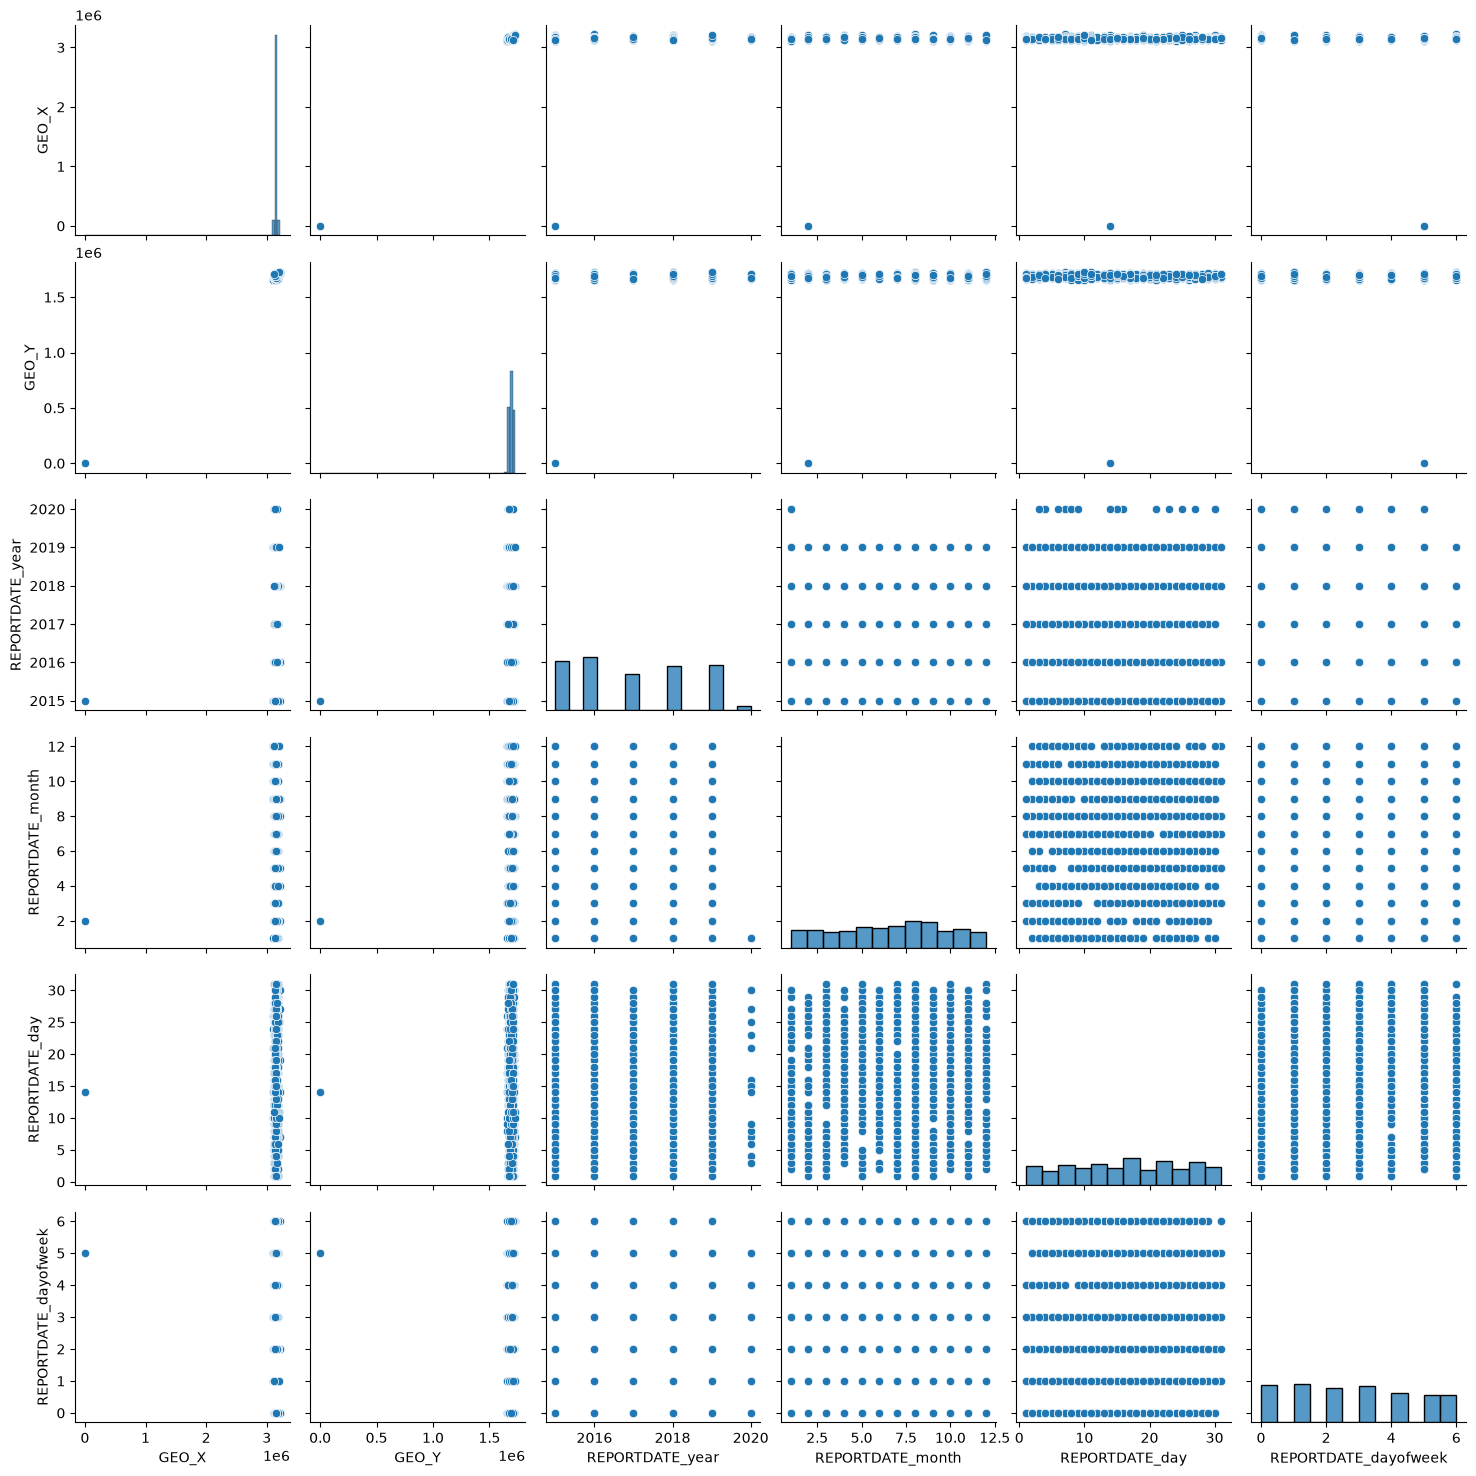

In [123]:
numeric_cols = [
    "GEO_X",
    "GEO_Y",
    "REPORTDATE_year",
    "REPORTDATE_month",
    "REPORTDATE_day",
    "REPORTDATE_dayofweek"
]
sns.pairplot(
    df[numeric_cols],
    diag_kind="hist"
)

plt.show()

# Scatter Plot - Numerical X and Numerical Y 

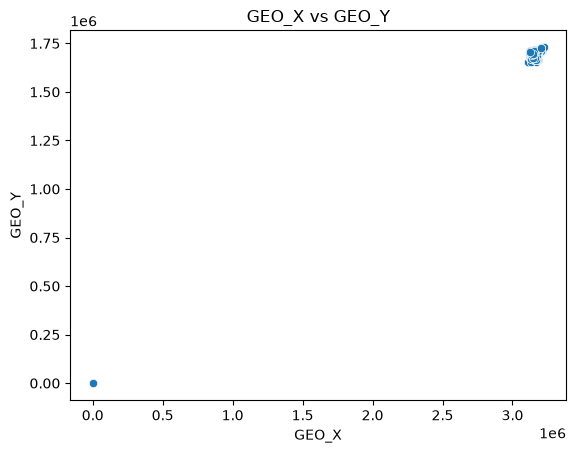

In [124]:
sns.scatterplot(
    data=df,
    x="GEO_X",
    y="GEO_Y"
)

plt.title("GEO_X vs GEO_Y")
plt.show()

# Line plot - X and Y 
`Useful when has an ordered relationship`

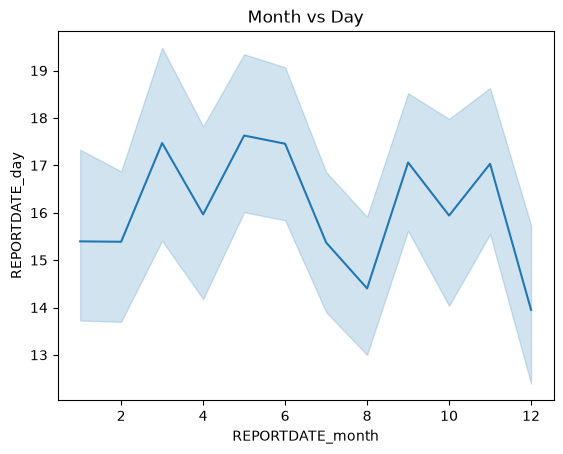

In [125]:
sns.lineplot(
    data=df,
    x="REPORTDATE_month",
    y="REPORTDATE_day"
)

plt.title("Month vs Day")
plt.show()

In [129]:
df.columns

Index(['FIRST_OCCURENCE_DATE', 'LAST_OCCURENCE_DATE', 'GEO_X', 'GEO_Y',
       'DISTRICT_ID', 'PRECINCT_ID', 'OFFENSE_CODE', 'OFFENSE_TYPE_ID',
       'OFFENSE_CATEGORY_ID', 'MJ_RELATION_TYPE', 'NEIGHBORHOOD_ID',
       'REPORTDATE_year', 'REPORTDATE_month', 'REPORTDATE_day',
       'REPORTDATE_dayofweek'],
      dtype='str')

In [137]:
df.head()

,FIRST_OCCURENCE_DATE,LAST_OCCURENCE_DATE,GEO_X,GEO_Y,DISTRICT_ID,PRECINCT_ID,OFFENSE_CODE,OFFENSE_TYPE_ID,OFFENSE_CATEGORY_ID,MJ_RELATION_TYPE,NEIGHBORHOOD_ID,REPORTDATE_year,REPORTDATE_month,REPORTDATE_day,REPORTDATE_dayofweek
0,06-MAR-17,06-MAR-17,3132526.0,1698468.0,1,121,3563,DRUG - MARIJUANA CULTIVATION,Drug Offenses,NON-INDUSTRY\r,sloan-lake,2017,3,6,0
1,03-JAN-18,03-JAN-18,3158749.0,1672408.0,3,314,2205,BURGLARY - BUSINESS NO FORCE,Burglary,INDUSTRY\r,university-hills,2018,1,3,2
2,03-JAN-18,03-JAN-18,3173094.0,1663993.0,3,323,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,hampden,2018,1,3,2
3,01-FEB-16,01-FEB-16,3152054.0,1712498.0,2,212,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,elyria-swansea,2016,2,1,0
4,21-MAY-16,21-MAY-16,3157004.0,1674967.0,3,312,2203,BURGLARY - BUSINESS BY FORCE,Burglary,INDUSTRY\r,cory-merrill,2016,5,21,5


# Crime incidents by month

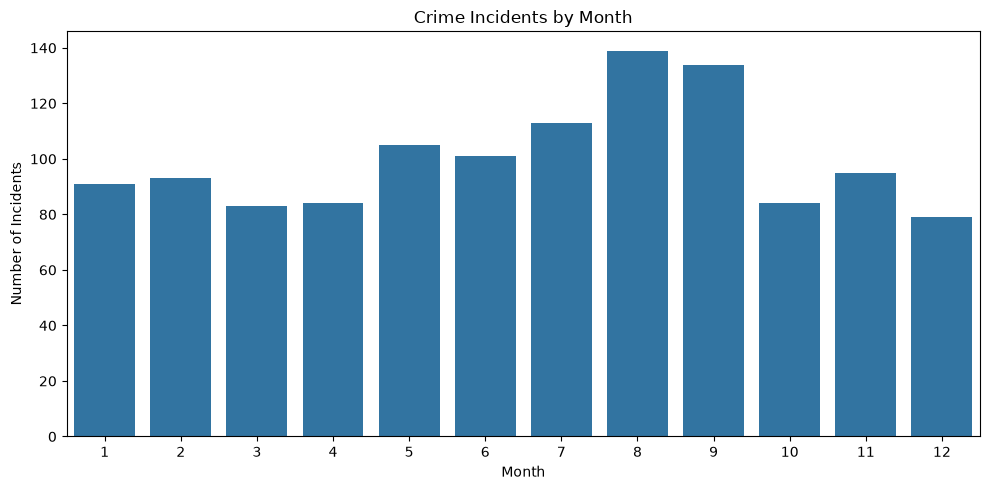

In [142]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="REPORTDATE_month"
)

plt.title("Crime Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.tight_layout()
plt.show()

# Crime frequency by day of week

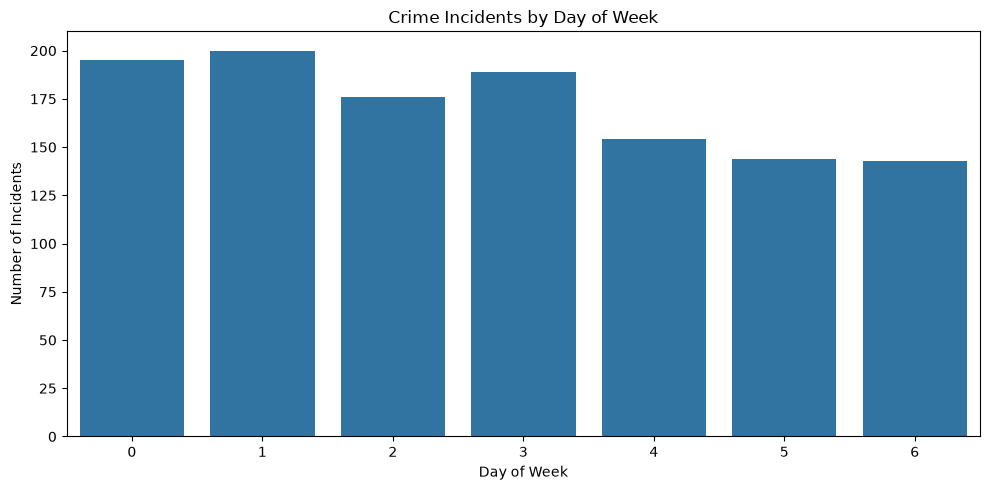

In [143]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="REPORTDATE_dayofweek"
)

plt.title("Crime Incidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")

plt.tight_layout()
plt.show()

In [152]:
unqu = df['OFFENSE_CATEGORY_ID'].unique()

print(unqu)
print(len(unqu))

<StringArray>
[             'Drug Offenses',                   'Burglary',
             'Agg ASLT-Other',   'Theft from Motor Vehicle',
                    'Larceny',         'Robbery-Street-Res',
             'Simple Assault',  'Criminal Mischief-Vehicle',
           'All Other Crimes', 'Criminal Mischief-Property',
           'Robbery-Business',            'Weapons Offense',
                 'Auto Theft',           'Agg ASLT-Firearm',
 'Criminal Mischief-Graffiti']
Length: 15, dtype: str
15


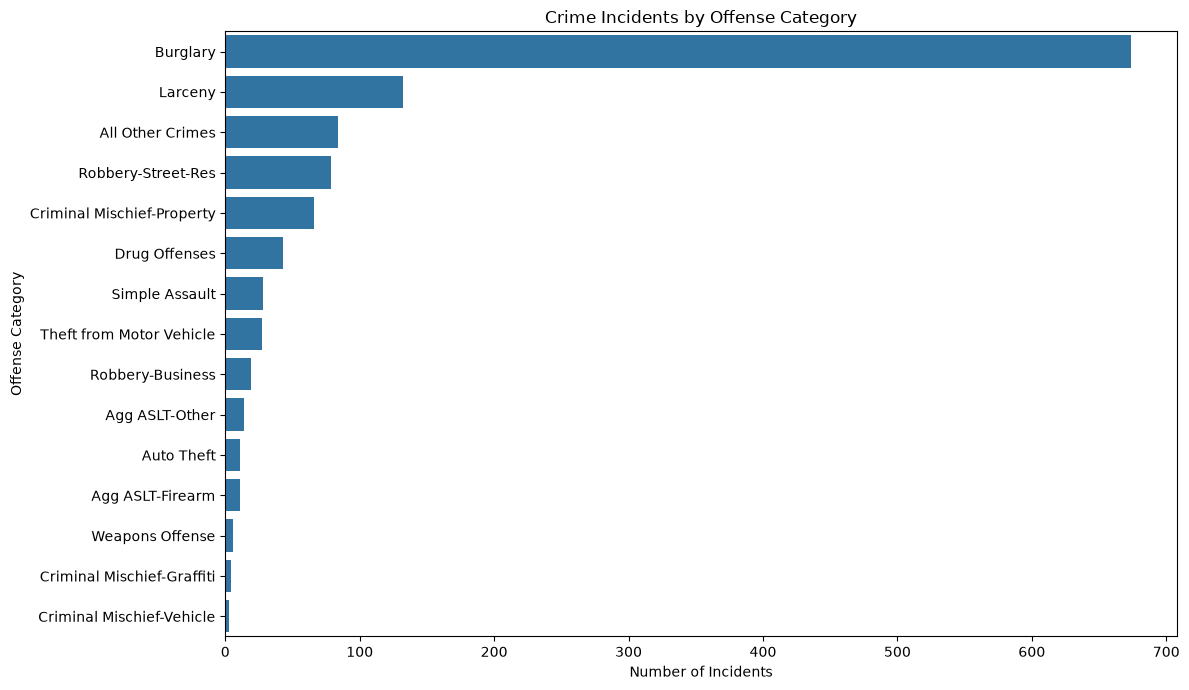

In [144]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="OFFENSE_CATEGORY_ID",
    order=df["OFFENSE_CATEGORY_ID"].value_counts().index
)

plt.title("Crime Incidents by Offense Category")
plt.xlabel("Number of Incidents")
plt.ylabel("Offense Category")

plt.tight_layout()
plt.show()